In [1]:
#Upload the Data
!wget "https://www.dropbox.com/scl/fi/qtcrzmsv4jz47cgvr2t0u/train.zip?rlkey=x3sz1h2o797inkqer67q7dg6b&e=1&dl=0" -O train.zip
#unzip the data
!unzip train.zip -d train

--2025-09-19 20:45:24--  https://www.dropbox.com/scl/fi/qtcrzmsv4jz47cgvr2t0u/train.zip?rlkey=x3sz1h2o797inkqer67q7dg6b&e=1&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6022:18::a27d:4212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc62f80f6315c61e27e3b9f5df75.dl.dropboxusercontent.com/cd/0/inline/CxpQPGTvFLLplSh3B8C1z7NiR6LSl0Zf0UoovYEti7EyUoSnWomh2sz7L9NDt32SfGLIX43mFPN4vUW6pqVa72eil6bTl35rnv-dybXqb8Higy0Y3eJNP-xTAdqaddTxBBUz_Ix82wjZkyIk91UvmZtV/file# [following]
--2025-09-19 20:45:25--  https://uc62f80f6315c61e27e3b9f5df75.dl.dropboxusercontent.com/cd/0/inline/CxpQPGTvFLLplSh3B8C1z7NiR6LSl0Zf0UoovYEti7EyUoSnWomh2sz7L9NDt32SfGLIX43mFPN4vUW6pqVa72eil6bTl35rnv-dybXqb8Higy0Y3eJNP-xTAdqaddTxBBUz_Ix82wjZkyIk91UvmZtV/file
Resolving uc62f80f6315c61e27e3b9f5df75.dl.dropboxusercontent.com (uc62f80f6315c61e27e3b9f5df75.dl.dropboxusercontent.com)... 162.125.2.1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.applications.mobilenet import MobileNet, preprocess_input
from keras.models import Model  #Functional API
from keras.layers import Flatten, Dense

from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

In [3]:
#editing pre trained model
base_model = MobileNet( input_shape=(224,224,3), include_top=False)

for layer in base_model.layers:
  layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(units=7, activation= 'softmax' )(x)

#model creation
model = Model(base_model.input, x)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,580,103 (13.66 MB)

 Trainable params: 351,239 (1.34 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [5]:
model.compile(optimizer='adam', loss= "categorical_crossentropy", metrics=['accuracy'])

In [6]:
train_datagen = ImageDataGenerator(
    zoom_range= 0.2,
    shear_range= 0.2,
    horizontal_flip=True,
    rescale = 1./255
)

train_data = train_datagen.flow_from_directory(directory= "train/train", target_size= (224,224), batch_size=32,)

train_data.class_indices

Found 350 images belonging to 7 classes.


{'Angry': 0,
 'Disguist': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

In [7]:
val_datagen = ImageDataGenerator(rescale= 1/255)

val_data = val_datagen.flow_from_directory(directory= "train/train", target_size= (224,224), batch_size=32,)

Found 350 images belonging to 7 classes.


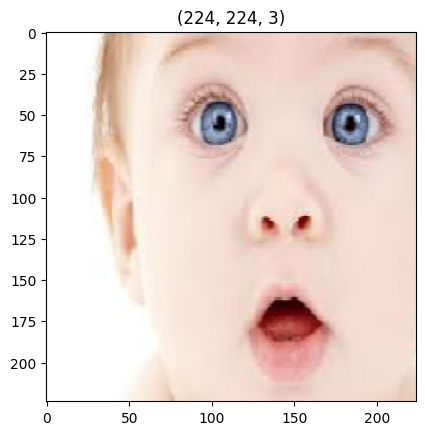

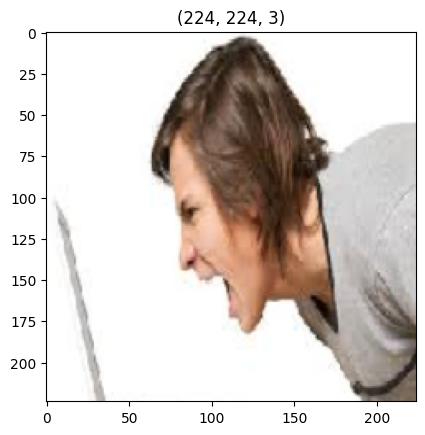

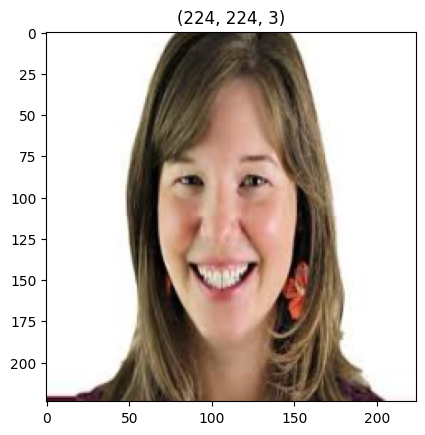

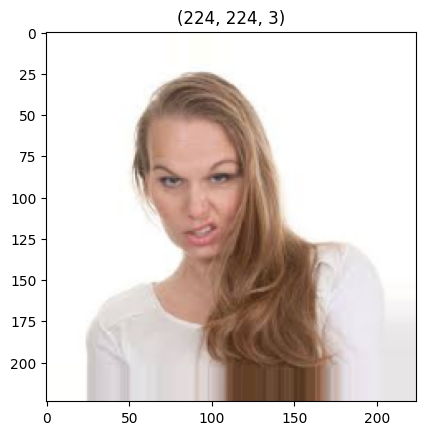

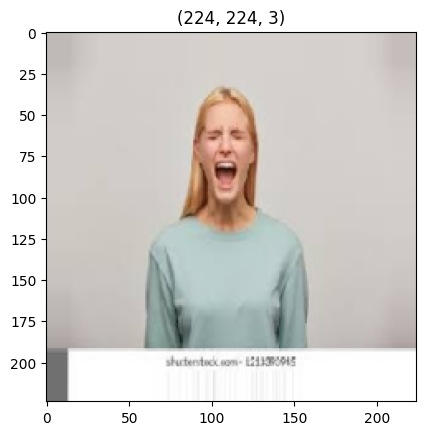

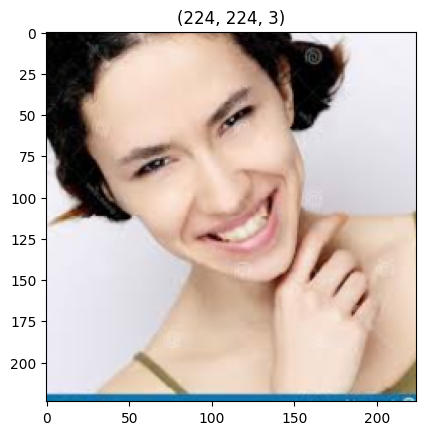

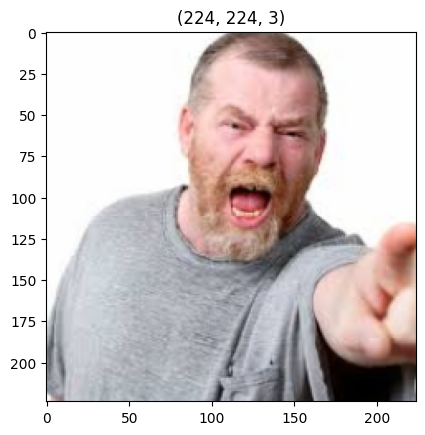

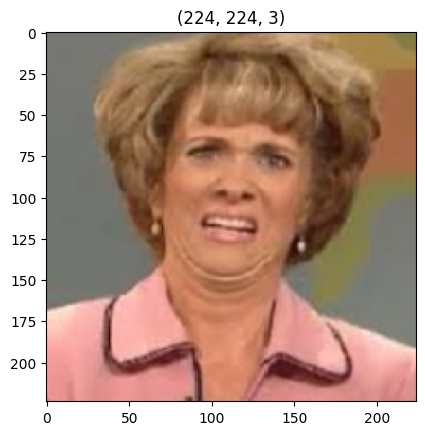

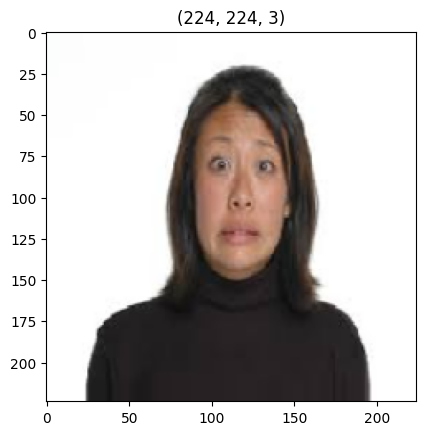

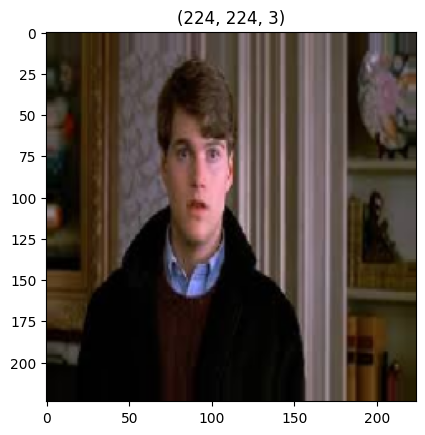

In [8]:
#visualize image in training data generator
t_img, label = train_data.__next__()

#func which will plot images
def plotImages(img_arr, label):
  """input = images array and output= images plotted"""
  count = 0
  for im, l in zip(img_arr,label) :
    plt.imshow(im)
    plt.title(im.shape)
    plt.axis = False
    plt.show()

    count +=1
    if count == 10:
      break

#plot img by calling func
plotImages(t_img, label)

In [9]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

#early stop
es= EarlyStopping(monitor='val_accuracy', min_delta= 0.01, patience= 5, verbose= 1, mode= 'max')

#model check point
mc = ModelCheckpoint(filepath="best_model.h5", monitor= 'val_accuracy', verbose= 1, save_best_only= True, mode='max')

call_back = [es, mc]

In [10]:
hist = model.fit(train_data, steps_per_epoch= 10, epochs= 30, validation_data= val_data, validation_steps= 8, callbacks= call_back)
#

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1896 - loss: 10.9996
Epoch 1: val_accuracy improved from -inf to 0.42188, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.1915 - loss: 11.0011 - val_accuracy: 0.4219 - val_loss: 7.3567
Epoch 2/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1875 - loss: 10.2499

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.42188 to 0.50781, saving model to best_model.h5


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.7635 - loss: 1.4299 - val_accuracy: 0.8398 - val_loss: 0.9863
Epoch 6/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7188 - loss: 1.5284
Epoch 6: val_accuracy improved from 0.83984 to 0.87500, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7188 - loss: 1.5284 - val_accuracy: 0.8750 - val_loss: 0.4991
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8710 - loss: 0.5493
Epoch 7: val_accuracy improved from 0.87500 to 0.94531, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8718 - loss: 0.5496 - val_accuracy: 0.9453 - val_loss: 0.1627
Epoch 8/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9062 - loss: 0.3404
Epoch 8: val_accuracy did not improve from 0.94531
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9062 - loss: 0.3404 - val_accuracy: 0.9297 - val_loss: 0.2404
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9123 - loss: 0.3764
Epoch 9: val_accuracy improved from 0.94531 to 0.95703, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.9126 - loss: 0.3760 - val_accuracy: 0.9570 - val_loss: 0.1785
Epoch 10/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9062 - loss: 0.2563
Epoch 10: val_accuracy did not improve from 0.95703
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9062 - loss: 0.2563 - val_accuracy: 0.9531 - val_loss: 0.1232
Epoch 11/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9053 - loss: 0.3232
Epoch 11: val_accuracy improved from 0.95703 to 0.99609, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.9076 - loss: 0.3188 - val_accuracy: 0.9961 - val_loss: 0.0248
Epoch 12/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9062 - loss: 0.2781
Epoch 12: val_accuracy did not improve from 0.99609
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 977ms/step - accuracy: 0.9062 - loss: 0.2781 - val_accuracy: 0.9805 - val_loss: 0.0454
Epoch 13/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9581 - loss: 0.1480
Epoch 13: val_accuracy did not improve from 0.99609
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.9579 - loss: 0.1478 - val_accuracy: 0.9648 - val_loss: 0.1300
Epoch 14/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8750 - loss: 0.5315
Epoch 14: val_accuracy did not improve from 0.99609
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8750 - loss: 0.5315 - val_accuracy: 0.9688 - val_loss: 0.0863
Epoch 15/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9606 - loss: 0.2042
Epoch 15: val_accuracy did not improve from 

In [11]:
#load best fit model
from keras.models import load_model
model = load_model("best_model.h5")

In [12]:
h = hist.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

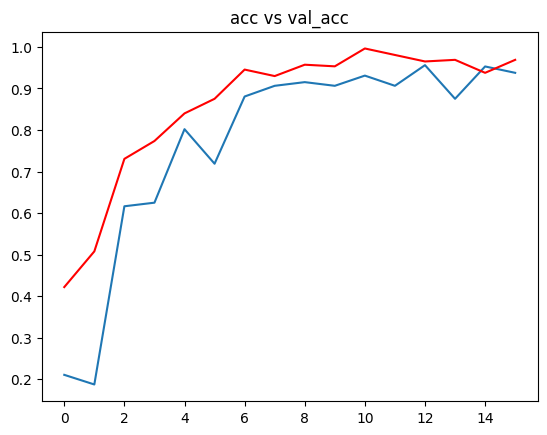

In [13]:
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c= "red")
plt.title("acc vs val_acc")
plt.show()

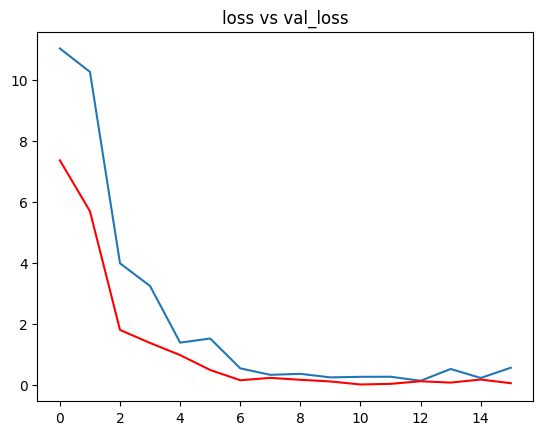

In [14]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c= "red")
plt.title("loss vs val_loss")
plt.show()

In [15]:
#map o/p values
op= dict(zip(train_data.class_indices.values(), train_data.class_indices.keys()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
 the image is of Happy


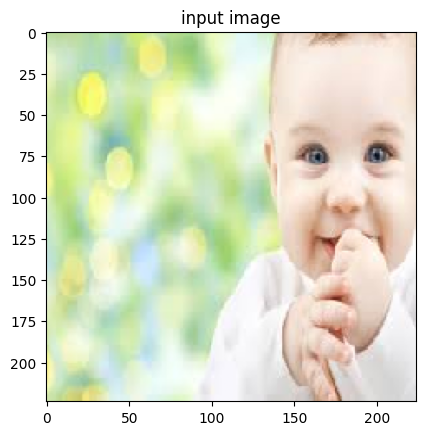

In [16]:
#testing if the prediction is right
path = "train/train/Happy/images (13).jpg" # Example path, replace with an actual image file
img = load_img(path, target_size= (224,224))

i = img_to_array(img)/255
input_arr = np.array([i])
input_arr.shape

pred = np.argmax(model.predict(input_arr))

print(f" the image is of {op[pred]}")

#displaying image
plt.imshow(input_arr[0])
plt.title("input image")
plt.show()

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import os
import shutil

# Define the path to the project folder in your Drive
# Changed to save directly in Colab Notebooks
drive_project_path = '/content/drive/My Drive/Colab Notebooks/my_image_classification_project'

# Create the project folder if it doesn't exist
os.makedirs(drive_project_path, exist_ok=True)

# Get the path to the current notebook file
# This assumes the notebook is in the default /content directory
notebook_path = '/content/' + os.path.basename(os.getcwd()) # This might need adjustment based on actual notebook path

# Copy the notebook file to the Drive folder
# You might need to manually find the notebook file name in the file explorer
try:
    # Replace 'Your_Notebook_Name.ipynb' with the actual name of your notebook file
    notebook_name = 'Untitled0.ipynb' # Replace with your notebook name
    shutil.copy(notebook_path + '/' + notebook_name, drive_project_path)
    print(f"Copied notebook to {drive_project_path}")
except FileNotFoundError:
    print(f"Notebook file not found. Please manually copy it from the file explorer or update the notebook_name variable.")


# Copy the best model file to the Drive folder
model_path = 'best_model.h5' # Path to your saved model
if os.path.exists(model_path):
    shutil.copy(model_path, drive_project_path)
    print(f"Copied model file to {drive_project_path}")
else:
    print(f"Model file '{model_path}' not found. Make sure you have trained and saved the model.")

print(f"Project files saved to: {drive_project_path}")

Notebook file not found. Please manually copy it from the file explorer or update the notebook_name variable.
Copied model file to /content/drive/My Drive/Colab Notebooks/my_image_classification_project
Project files saved to: /content/drive/My Drive/Colab Notebooks/my_image_classification_project
